<!-- AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 1 notebook and the bonus report as designed in the grilling rounds', Date: 2026-10-06 -->
<!-- AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Write the root README and a Task 1 REFLECTION as decided in the grilling round', Date: 2026-10-07 -->

# Task 1: LLM-powered equity research assistant

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sathudeva7/CDAZZDEV-MLE-SATHURSAN/blob/main/task1_financial/task1_equity_research.ipynb)

This notebook is a thin driver. The logic lives in the `task1_financial/` modules
and in `common/` (the structured LLM helper and the Jev client), which carry
offline tests in `tests/`. Each section below matches one rubric row, says what it
shows, and names the file that does the work. Results are printed by code cells
only, so no number in the text can drift from the run.

| Rubric row | Section | Where the logic lives |
|---|---|---|
| 1A OHLCV data fetch | 1A.1 | `task1_financial/data.py` |
| 1A Indicator accuracy | 1A.2 | `task1_financial/indicators.py` |
| 1A News retrieval | 1A.3 | `task1_financial/news.py` |
| 1A Summary dictionary | 1A.4 | `task1_financial/summary.py`, `signals.py` |
| 1A Robustness | 1A.5 | every module: warnings instead of exceptions |
| 1B Per-headline JSON | 1B.1 | `task1_financial/sentiment.py`, `schemas.py` |
| 1B Signal reasoning quality | 1B.2 | `task1_financial/recommendation.py` |
| 1B Structured output validation | 1B.3 | `common/llm.py`, `task1_financial/schemas.py` |
| 1B Prompt engineering | 1B.4 | `task1_financial/prompts.py` |
| Bonus report rendering | Bonus | `task1_financial/report.py` |

**Models.** The submitted run uses the `free` LLM profile: Groq's free tier
(`openai/gpt-oss-120b`) with an OpenRouter free model as fallback. One deliberate
exception to the free-tier setup: **Jev** (TypeSafe's decision model, a paid API)
labels each headline's sentiment, because it returns measured probabilities
instead of a self-reported confidence. The LLM writes the reason and the
Recommendation (`docs/adr/0001-jev-decides-llm-explains.md`). Without
`JEV_API_KEY` the LLM labels every headline, so the notebook runs fully on free tiers.

**To run it yourself:** add `GROQ_API_KEY` (and optionally `OPENROUTER_API_KEY`
and `JEV_API_KEY`) under Colab's Secrets (the key icon), then Runtime → Run all.

## Setup

In [12]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 1 notebook and the bonus report as designed in the grilling rounds', Date: 2026-10-06
import os
import subprocess
import sys
import time
from pathlib import Path

RUN_STARTED = time.perf_counter()
TICKER = "AAPL"
REPO_URL = "https://github.com/sathudeva7/CDAZZDEV-MLE-SATHURSAN"
REPO_REF = "main"  # the branch or tag the Colab run clones
SUBMISSION_PROFILE = "free"  # set here, not from the shell, so a local paid_dev setting cannot leak in
KEY_NAMES = ["GROQ_API_KEY", "OPENROUTER_API_KEY", "JEV_API_KEY"]

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    ROOT = Path("/content") / REPO_URL.rsplit("/", 1)[-1]
    if ROOT.exists():
        subprocess.run(["git", "-C", str(ROOT), "pull", "--quiet"], check=True)
    else:
        subprocess.run(["git", "clone", "--quiet", "--depth", "1", "--branch", REPO_REF, REPO_URL, str(ROOT)], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-r", str(ROOT / "requirements.txt")], check=True)
else:
    # Locally the notebook runs from task1_financial/, one level below the repo root.
    ROOT = Path.cwd().parent if Path.cwd().name == "task1_financial" else Path.cwd()
    from dotenv import load_dotenv
    load_dotenv(ROOT / ".env")
sys.path.insert(0, str(ROOT))
os.environ["LLM_PROFILE"] = SUBMISSION_PROFILE

from common.llm import enable_console_logging
from common.llm_config import active_profile, secret

enable_console_logging()
profile = active_profile()
commit = subprocess.run(["git", "-C", str(ROOT), "rev-parse", "--short", "HEAD"], capture_output=True, text=True, check=False).stdout.strip()  # the hash is informational
print(f"Running in {'Colab' if IN_COLAB else 'a local kernel'}, repo at {commit or 'unknown commit'}")
print(f"LLM profile: {profile.name} (primary {profile.primary.name}: {profile.primary.model}; "
      f"fallback {profile.fallback.name + ': ' + profile.fallback.model if profile.fallback else 'none'})")
for name in KEY_NAMES:  # presence only, never the value
    print(f"  {'✓' if secret(name) else '✗'} {name}")

Running in Colab, repo at 89f841d
LLM profile: free (primary groq: openai/gpt-oss-120b; fallback openrouter: nvidia/nemotron-3-super-120b-a12b:free)
  ✓ GROQ_API_KEY
  ✗ OPENROUTER_API_KEY
  ✗ JEV_API_KEY


In [13]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 1 notebook and the bonus report as designed in the grilling rounds', Date: 2026-10-06
# One run, one log: the call log is cleared so the committed file matches this notebook's outputs exactly.
from task1_financial.pipeline import LOG_DIR

CALL_LOG = LOG_DIR / profile.log_file
CALL_LOG.unlink(missing_ok=True)
print("Every LLM and Jev request of this run is logged to", CALL_LOG.relative_to(ROOT))

Every LLM and Jev request of this run is logged to task1_financial/logs/llm_calls.jsonl


## 1A.1 OHLCV data fetch

`run_market_data` fetches the daily bars with `yfinance`, adds the indicators,
the momentum signal, the fundamentals, the summary and the headlines. The
window is computed from today's date in New York (`LOOKBACK_YEARS = 2`), never
from a date string, and prices are split- and dividend-adjusted.

In [14]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 1 notebook and the bonus report as designed in the grilling rounds', Date: 2026-10-06
import inspect
import json

import pandas as pd

from task1_financial import data
from task1_financial.pipeline import run_market_data

market = run_market_data(TICKER)
prices = market.prices
first, last = prices.index[0].date(), prices.index[-1].date()
print(f"{TICKER}: {len(prices)} daily bars from {first} to {last} ({(last - first).days / 365.25:.2f} years, LOOKBACK_YEARS = {data.LOOKBACK_YEARS})")
print(inspect.getsource(data.fetch_ohlcv).split('    warnings')[0])  # how the window is computed
prices[data.OHLCV_COLUMNS].tail()

INFO:task1_financial.data:AAPL: 501 daily bars from 2024-10-08 to 2026-10-07
INFO:task1_financial.data:retrying AAPL yahoo news in 1s (attempt 2 of 3): HTTPError: HTTP Error 429: Too Many Requests
INFO:task1_financial.data:retrying AAPL yahoo news in 2s (attempt 3 of 3): HTTPError: HTTP Error 429: Too Many Requests
INFO:task1_financial.news:AAPL yahoo feed: 0 items, 0 recent, 0 new
INFO:task1_financial.news:AAPL google feed: 100 items, 54 recent, 52 new


AAPL: 501 daily bars from 2024-10-08 to 2026-10-07 (2.00 years, LOOKBACK_YEARS = 2)
def fetch_ohlcv(ticker: str, today: date) -> PriceHistory:
    """Cleaned daily OHLCV bars for the LOOKBACK_YEARS up to and including `today`."""
    end = today + timedelta(days=1)
    start = (pd.Timestamp(end) - pd.DateOffset(years=LOOKBACK_YEARS)).date()



,Open,High,Low,Close,Volume
Date,,,,,
2026-10-01,330.000000,332.480011,325.809998,330.320007,36306300
2026-10-02,333.260010,334.540009,330.609985,333.690002,33278600
2026-10-05,332.820007,336.209991,331.649994,332.890015,34400900
2026-10-06,332.279999,334.380005,330.619995,333.630005,30425700
2026-10-07,337.015015,338.670013,332.790009,334.420013,5327387


## 1A.2 Indicators from first principles

Every indicator is written with pandas and numpy only, in
`task1_financial/indicators.py`. The conventions follow StockCharts' worked
examples, and `tests/test_indicators.py` checks them against those published
values to 1e-6:

- **SMA**: plain rolling mean.
- **EMA** (used by MACD): k = 2 / (span + 1), seeded with the SMA of the first `span` values.
- **RSI 14**: Wilder smoothing, avg = (previous avg × 13 + today) / 14, seeded with a plain mean; RSI = 100 − 100 / (1 + avg gain / avg loss).
- **MACD (12, 26, 9)**: EMA12 − EMA26; signal = EMA9 of MACD; histogram = MACD − signal.
- **Bollinger (20, 2)**: SMA20 ± 2 × the *population* standard deviation (ddof = 0, Bollinger's definition; pandas defaults to the sample one).

The source, as it runs:

In [15]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 1 notebook and the bonus report as designed in the grilling rounds', Date: 2026-10-06
from task1_financial import indicators

for function in (indicators.sma, indicators.ema, indicators.rsi, indicators.macd, indicators.bollinger, indicators._seeded_smoothing):
    print(inspect.getsource(function))

def sma(close: pd.Series, window: int) -> pd.Series:
    """Simple moving average of the last `window` prices."""
    _warn_if_short(close, window, f"SMA({window})")
    return close.rolling(window, min_periods=window).mean()

def ema(values: pd.Series, span: int) -> pd.Series:
    """Exponential moving average, seeded with the SMA of the first `span` values.

    Leading NaNs are skipped, so this also smooths a series that starts late,
    such as the MACD line when building the signal line.
    """
    _warn_if_short(values, span, f"EMA({span})")
    return _ema(values, span)

def rsi(close: pd.Series, period: int = RSI_PERIOD) -> pd.Series:
    """Relative Strength Index with Wilder smoothing, from 0 to 100."""
    _warn_if_short(close, period + 1, f"RSI({period})")
    change = close.diff()
    gains = change.clip(lower=0)
    losses = (-change).clip(lower=0)
    # Wilder smoothing is an EMA with alpha = 1 / period, seeded with a plain mean.
    avg_gain = _seeded_smoothing(gains, 

**Independent check.** The cell below recomputes each indicator for the latest bar
a second way, with plain numpy and explicit loops rather than pandas' rolling and
`ewm`, and asserts that the module's value matches.

In [16]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 1 notebook and the bonus report as designed in the grilling rounds', Date: 2026-10-06
import numpy as np

TOLERANCE = 1e-8
close = prices["Close"].to_numpy(dtype=float)
latest = prices.iloc[-1]


def ema_loop(values, span):
    """EMA as an explicit loop: seed with the mean of the first `span` values, then y += k * (x - y)."""
    k = 2 / (span + 1)
    out = [values[:span].mean()]
    for value in values[span:]:
        out.append(out[-1] + k * (value - out[-1]))
    return np.array(out)  # out[0] belongs to bar span - 1


def wilder_rsi_loop(values, period):
    change = np.diff(values)
    gains, losses = np.clip(change, 0, None), np.clip(-change, 0, None)
    avg_gain, avg_loss = gains[:period].mean(), losses[:period].mean()
    for gain, loss in zip(gains[period:], losses[period:]):
        avg_gain = (avg_gain * (period - 1) + gain) / period
        avg_loss = (avg_loss * (period - 1) + loss) / period
    return 100 - 100 / (1 + avg_gain / avg_loss)


macd_line = ema_loop(close, indicators.MACD_FAST_SPAN)[indicators.MACD_SLOW_SPAN - indicators.MACD_FAST_SPAN:] - ema_loop(close, indicators.MACD_SLOW_SPAN)
signal_line = ema_loop(macd_line, indicators.MACD_SIGNAL_SPAN)
band = close[-indicators.BB_WINDOW:]

checks = {
    indicators.COL_SMA_SHORT: close[-indicators.SMA_SHORT_WINDOW:].mean(),
    indicators.COL_SMA_LONG: close[-indicators.SMA_LONG_WINDOW:].mean(),
    indicators.COL_RSI: wilder_rsi_loop(close, indicators.RSI_PERIOD),
    indicators.COL_MACD: macd_line[-1],
    indicators.COL_MACD_SIGNAL: signal_line[-1],
    indicators.COL_MACD_HIST: macd_line[-1] - signal_line[-1],
    indicators.COL_BB_MIDDLE: band.mean(),
    indicators.COL_BB_UPPER: band.mean() + indicators.BB_NUM_STD * band.std(ddof=0),
    indicators.COL_BB_LOWER: band.mean() - indicators.BB_NUM_STD * band.std(ddof=0),
}
rows = [{"indicator": col, "module": latest[col], "recomputed": value, "abs diff": abs(latest[col] - value)} for col, value in checks.items()]
check_table = pd.DataFrame(rows)
assert (check_table["abs diff"] < TOLERANCE).all(), check_table
assert 0 <= latest[indicators.COL_RSI] <= 100
print(f"All {len(checks)} values match to within {TOLERANCE:g} on {last}.")
check_table

All 9 values match to within 1e-08 on 2026-10-07.


,indicator,module,recomputed,abs diff
0,sma_50,322.191198,322.191198,0.000000e+00
1,sma_200,289.721582,289.721582,0.000000e+00
2,rsi_14,55.430900,55.430900,0.000000e+00
3,macd,3.102883,3.102883,5.684342e-14
4,macd_signal,4.067353,4.067353,2.575717e-14
5,macd_hist,-0.964470,-0.964470,3.108624e-14
6,bb_middle,334.365501,334.365501,0.000000e+00
7,bb_upper,341.532537,341.532537,8.185452e-12
8,bb_lower,327.198466,327.198466,8.185452e-12


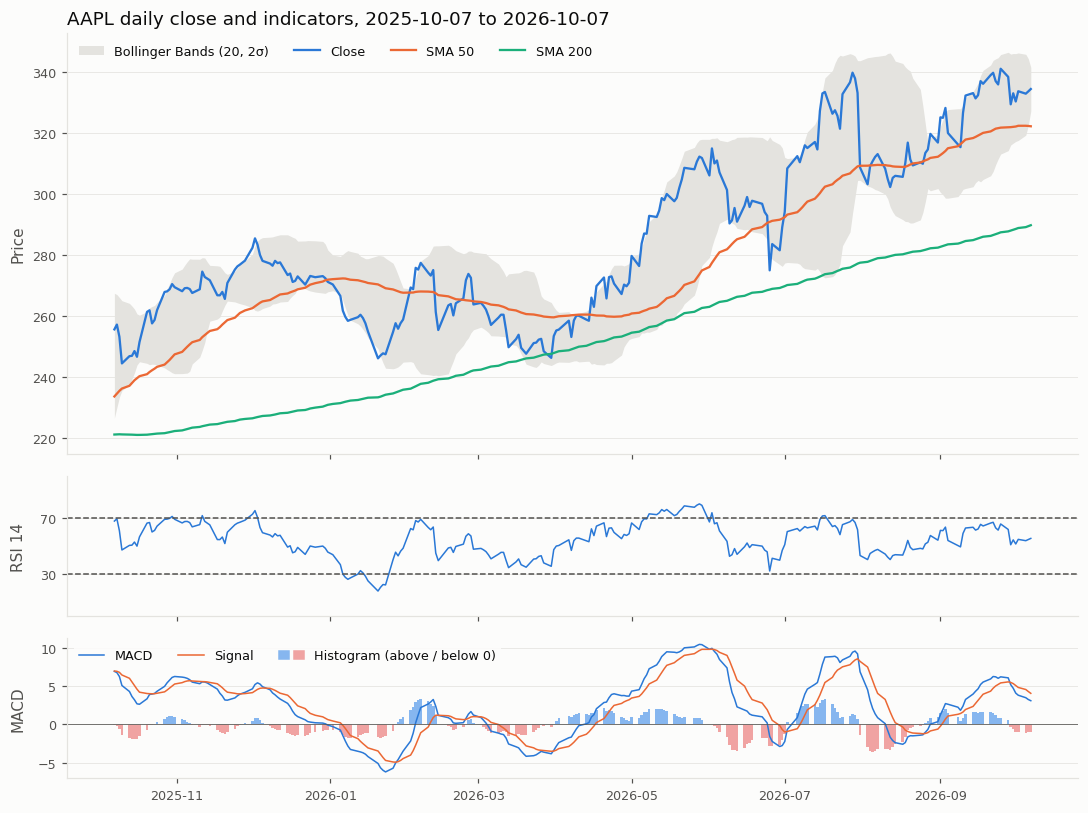

In [17]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 1 notebook and the bonus report as designed in the grilling rounds', Date: 2026-10-06
from task1_financial.report import plot_price_chart

plot_price_chart(prices, TICKER)

## 1A.3 News headlines

`fetch_headlines` reads Yahoo Finance's RSS feed first, then tops up from Google
News RSS (`"{ticker} stock"`). It keeps the last 7 days, removes duplicate
titles (keeping Yahoo's copy), and asks for 15 so that ten survive even after
duplicates. Both feeds are free and need no key.

In [18]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 1 notebook and the bonus report as designed in the grilling rounds', Date: 2026-10-06
from task1_financial.news import MIN_HEADLINES

print(f"{len(market.headlines)} headlines (minimum {MIN_HEADLINES}), newest first")
pd.DataFrame(
    [{"published (UTC)": h.published.strftime("%Y-%m-%d %H:%M"), "feed": h.feed, "publisher": h.publisher, "headline": h.title} for h in market.headlines]
)

15 headlines (minimum 10), newest first


,published (UTC),feed,publisher,headline
0,2026-10-07 13:20,google,24/7 Wall St.,Apple’s New CEO Just Sold $8.5 Million of Stock
1,2026-10-07 08:33,google,Simply Wall Street,Apple (AAPL) Shares Enter 24 7 Token Trading P...
2,2026-10-07 07:43,google,MarketBeat,"21,189 Apple Inc. $AAPL Shares Purchased by Mu..."
3,2026-10-07 03:41,google,The Globe and Mail,Nvidia Is About 4% From Becoming the First $6 ...
4,2026-10-06 18:00,google,AOL.com,3 Ways New Investors Get Apple Stock Wrong
5,2026-10-06 14:25,google,Trefis,What Would It Take For Apple Stock To Move Hig...
6,2026-10-06 14:07,google,Investing.com,UBS reiterates Apple stock neutral on slowing ...
7,2026-10-06 12:35,google,24/7 Wall St.,Apple (AAPL) Trading Above Analyst Targets as ...
8,2026-10-06 12:01,google,Yahoo Finance,Apple Inc. (AAPL) Stock Forecasts
9,2026-10-06 09:33,google,Finbold,Monster insider trading alert for Apple stock


## 1A.4 Summary dictionary

`build_summary` returns a validated `MarketSummary`, dumped to a plain dict.
The required fields come first below; the rest records how each was reached.
The momentum signal is rule-based: five votes (price vs SMA 50, SMA 50 vs
SMA 200, MACD vs signal, MACD histogram direction, RSI vs 50), summed from −5 to +5.

In [19]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 1 notebook and the bonus report as designed in the grilling rounds', Date: 2026-10-06
REQUIRED_FIELDS = ["current_price", "high_52w", "low_52w", "pe_ratio", "ytd_return_pct"]
summary = market.summary
for field in REQUIRED_FIELDS:
    print(f"{field:>15}: {summary[field]}")
print(f"{'momentum':>15}: {summary['momentum']['label']} (score {summary['momentum']['score']:+d})")
print()
print(json.dumps(summary, indent=2, default=str))

  current_price: 334.42
       high_52w: 345.34
        low_52w: 242.76
       pe_ratio: 38.34
 ytd_return_pct: 23.35
       momentum: Bullish (score +3)

{
  "ticker": "AAPL",
  "company_name": "Apple Inc.",
  "currency": "USD",
  "as_of": "2026-10-07",
  "current_price": 334.42,
  "high_52w": 345.34,
  "low_52w": 242.76,
  "pe_ratio": 38.34,
  "ytd_return_pct": 23.35,
  "momentum": {
    "as_of": "2026-10-07",
    "label": "Bullish",
    "score": 3,
    "votes": [
      {
        "name": "short_term_trend",
        "inputs": {
          "close": 334.4200134277344,
          "sma_50": 322.1911981201172
        },
        "vote": 1,
        "reason": "close 334.4 is above sma_50 322.2"
      },
      {
        "name": "long_term_regime",
        "inputs": {
          "sma_50": 322.1911981201172,
          "sma_200": 289.7215822601318
        },
        "vote": 1,
        "reason": "sma_50 322.2 is above sma_200 289.7"
      },
      {
        "name": "macd_crossover",
        "inputs":

## 1A.5 Robustness

Data problems never raise. Each fallback is logged and listed in
`summary['warnings']`, and missing values are `None`. Here the pipeline is given
a ticker that does not exist: it retries, gives up, and still returns a complete
result. Thresholds and windows are named constants, listed after it.

In [20]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 1 notebook and the bonus report as designed in the grilling rounds', Date: 2026-10-06
bad = run_market_data("NOTATICKERZZ")
print("bars:", len(bad.prices), "| headlines:", len(bad.headlines), "| current_price:", bad.summary["current_price"])
print("momentum:", bad.summary["momentum"]["label"], "| unavailable votes:", bad.summary["momentum"]["unavailable"])
print("warnings:")
for warning in bad.summary["warnings"]:
    print(" -", warning)

ERROR:yfinance:$NOTATICKERZZ: possibly delisted; no timezone found
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['NOTATICKERZZ']: possibly delisted; no timezone found
INFO:task1_financial.data:retrying NOTATICKERZZ price history in 1s (attempt 2 of 3): empty result
ERROR:yfinance:$NOTATICKERZZ: possibly delisted; no timezone found
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['NOTATICKERZZ']: possibly delisted; no timezone found
INFO:task1_financial.data:retrying NOTATICKERZZ price history in 2s (attempt 3 of 3): empty result
ERROR:yfinance:$NOTATICKERZZ: possibly delisted; no timezone found
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['NOTATICKERZZ']: possibly delisted; no timezone found
ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: NOTATICKERZZ"}}}
INFO:task1_financial.data:retrying NOTATICKERZZ yahoo news in 1s (attempt 2 of 3): HTTPError: HTTP Error 429: Too Many Requests
INFO:tas

bars: 0 | headlines: 0 | current_price: None
momentum: Neutral | unavailable votes: ['short_term_trend', 'long_term_regime', 'macd_crossover', 'macd_acceleration', 'rsi_momentum']
warnings:
 - no NOTATICKERZZ price history after 3 attempts (last problem: empty result); check the ticker symbol or try later
 - no NOTATICKERZZ yahoo news after 3 attempts (last problem: HTTPError: HTTP Error 429: Too Many Requests); check the ticker symbol or try later
 - no NOTATICKERZZ google news after 3 attempts (last problem: empty result); check the ticker symbol or try later
 - only 0 headlines for NOTATICKERZZ in the last 7 days, below the minimum of 10
 - NOTATICKERZZ: no prices, so current price, 52-week range and YTD return are empty
 - P/E unavailable: Yahoo returned neither trailingPE nor trailing EPS


In [21]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 1 notebook and the bonus report as designed in the grilling rounds', Date: 2026-10-06
# No magic numbers: every window, period and threshold is a named constant.
{name: value for name, value in vars(indicators).items() if name.isupper() and isinstance(value, (int, float))}

{'SMA_SHORT_WINDOW': 50,
 'SMA_LONG_WINDOW': 200,
 'RSI_PERIOD': 14,
 'MACD_FAST_SPAN': 12,
 'MACD_SLOW_SPAN': 26,
 'MACD_SIGNAL_SPAN': 9,
 'BB_WINDOW': 20,
 'BB_NUM_STD': 2.0,
 'VOLATILITY_WINDOW': 30,
 'TRADING_DAYS_PER_YEAR': 252,
 'BB_DDOF': 0,
 'VOLATILITY_DDOF': 1,
 'FLAT_BAND_PCT_B': 0.5,
 'FLAT_PRICE_RSI': 50.0,
 'MAX_RSI': 100.0,
 'ZERO_WIDTH_TOLERANCE': 1e-12}

## Task 1B: run the analysis

`run_analysis` scores every headline (Jev decides, the LLM explains), averages
the Sentiment score, then asks the LLM for a Buy, Hold or Sell call. Every
request goes through `common/llm.py` or `common/jev.py`, which validate the
answer and log it.

In [22]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 1 notebook and the bonus report as designed in the grilling rounds', Date: 2026-10-06
from task1_financial.pipeline import run_analysis

analysis = run_analysis(market)
print("analysis warnings:", analysis.warnings or "none")

ERROR:common.llm:headline_sentiment_llm fell back to the caller's default value: groq: BadRequestError 400: Error code: 400 - {'error': {'message': "Parsing failed. The model generated output that could not be parsed. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'output_parse_failed', 'failed_generation': "We need sentiment. It's about dividend amount needed. Likely neutral; informational. Might be slightly positive as highlights dividend but not news. Probably neutral. confidence 0.7."}}
INFO:task1_financial.sentiment:1 of 15 headlines could not be scored and are left out of the Sentiment score


analysis warnings: ['Jev was unavailable for 14 headlines, so the LLM labelled them', '1 headlines could not be scored and are left out of the Sentiment score']


## 1B.1 Per-headline JSON and the Sentiment score

Each headline becomes a `HeadlineSentiment` with the brief's four fields
(`headline`, `sentiment`, `confidence`, `brief_reason`), plus where the label came
from (`scored_by`), Jev's probabilities, and the headline's `score`.

**Aggregation.** A headline's score is p(positive) − p(negative) from Jev's
probabilities, from −1 to +1. A neutral-leaning headline therefore counts for
little, rather than being forced to ±1. When the LLM labelled the headline, the
score is sign × confidence. The **Sentiment score** is the mean over scored
headlines, labelled positive above +0.2, negative below −0.2, and neutral otherwise.

In [23]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 1 notebook and the bonus report as designed in the grilling rounds', Date: 2026-10-06
print("One record, as JSON:")
print(analysis.headline_sentiments[0].model_dump_json(indent=2))

One record, as JSON:
{
  "headline": "Apple’s New CEO Just Sold $8.5 Million of Stock",
  "sentiment": "negative",
  "confidence": 0.88,
  "brief_reason": "Insider selling by the CEO suggests reduced confidence, likely pressuring the share price.",
  "probabilities": null,
  "scored_by": "llm",
  "score": -0.88
}


In [24]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 1 notebook and the bonus report as designed in the grilling rounds', Date: 2026-10-06
pd.set_option("display.max_colwidth", 140)
headline_table = pd.DataFrame([item.model_dump(exclude={"probabilities"}) for item in analysis.headline_sentiments])
headline_table

,headline,sentiment,confidence,brief_reason,scored_by,score
0,Apple’s New CEO Just Sold $8.5 Million of Stock,negative,0.88,"Insider selling by the CEO suggests reduced confidence, likely pressuring the share price.",llm,-0.88
1,Apple (AAPL) Shares Enter 24 7 Token Trading Plan In 63 Stock Filing,neutral,0.68,The filing mentions a new token trading plan but its impact on earnings or demand is unclear.,llm,0.00
2,"21,189 Apple Inc. $AAPL Shares Purchased by Munich Reinsurance Co Stock Corp in Munich",positive,0.90,"Institutional buying signals demand and confidence, likely supporting the share price.",llm,0.90
3,Nvidia Is About 4% From Becoming the First $6 Trillion Company. History Says the Milestone Itself Tells You Little.,neutral,0.75,Apple is only mentioned in passing; the news focuses on Nvidia and has no direct impact on Apple’s fundamentals.,llm,0.00
4,3 Ways New Investors Get Apple Stock Wrong,neutral,0.70,"The article critiques investors' behavior, not Apple’s fundamentals, so impact on share price is unclear.",llm,0.00
5,What Would It Take For Apple Stock To Move Higher?,neutral,0.75,"Speculative question without new information; no clear impact on earnings, demand, costs, or other drivers.",llm,0.00
6,UBS reiterates Apple stock neutral on slowing App Store growth,negative,0.78,"Analyst downgrade due to weaker App Store revenue growth, suggesting lower future earnings.",llm,-0.78
7,Apple (AAPL) Trading Above Analyst Targets as Memory Costs Crimp Margin Outlook,negative,0.73,"Higher memory component costs erode margins, weighing on investor expectations despite current price above targets.",llm,-0.73
8,Apple Inc. (AAPL) Stock Forecasts,neutral,0.60,"Generic forecast mention without clear direction, so impact on share price is unclear.",llm,0.00
9,Monster insider trading alert for Apple stock,negative,0.85,"Alert of significant insider trading raises concerns about potential negative information, likely pressuring the share price.",llm,-0.85


In [25]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 1 notebook and the bonus report as designed in the grilling rounds', Date: 2026-10-06
scores = [item.score for item in analysis.headline_sentiments if item.score is not None]
print(f"mean of {len(scores)} headline scores = {sum(scores) / len(scores):+.4f}" if scores else "no headline scored")
print(analysis.sentiment.model_dump_json(indent=2))

mean of 14 headline scores = -0.4100
{
  "score": -0.41,
  "label": "negative",
  "scored": 14,
  "by_jev": 0,
  "by_llm": 14,
  "failed": 1,
  "counts": {
    "positive": 1,
    "negative": 8,
    "neutral": 5
  }
}


## 1B.2 Signal reasoning

The LLM is given **facts, not a verdict**. Each fact pairs a raw value with a
relationship computed in code: distance from each moving average, whether the
SMA gap is widening, which way RSI and the MACD histogram are moving, %B and the
52-week position. The rule-based momentum label is deliberately withheld, so the
model has to combine the indicators itself. The prompt asks that every sentence
connect at least two facts, and the schema enforces 3–5 sentences.

In [26]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 1 notebook and the bonus report as designed in the grilling rounds', Date: 2026-10-06
recommendation = analysis.recommendation
print("Facts the LLM received:")
for fact in recommendation.facts:
    print(" -", fact)
print()
print(f"Rule-based momentum signal (not shown to the LLM): {summary['momentum']['label']} ({summary['momentum']['score']:+d})")
print(f"LLM provider: {recommendation.provider} | ok: {recommendation.ok}")
print(recommendation.value.model_dump_json(indent=2))

Facts the LLM received:
 - Close: 334.42 USD
 - Close vs 50-day SMA (322.19): +3.8%
 - Close vs 200-day SMA (289.72): +15.4%
 - 50-day SMA vs 200-day SMA: +11.2% now, +12.1% 10 trading days ago (gap narrowing)
 - RSI-14: 55.4 now, 54.4 5 trading days ago (rising); overbought above 70, oversold below 30
 - MACD: 3.10, signal line 4.07 (MACD below the signal line); histogram -0.96 now, -1.05 the day before (rising)
 - Bollinger %B: 0.50 (0 is the lower band, 1 the upper band; outside 0 to 1 is outside the bands)
 - 52-week range: low 242.76, high 345.34; close at 89% of the range
 - 30-day annualised volatility: 21.0%
 - Year-to-date return: +23.4%
 - Sentiment score: -0.41 (negative) on a scale from -1 to +1, from 14 headlines of the last 7 days (1 positive, 8 negative, 5 neutral)

Rule-based momentum signal (not shown to the LLM): Bullish (+3)
LLM provider: groq | ok: True
{
  "recommendation": "Hold",
  "justification": "Apple is trading well above both the 50‑day and 200‑day moving a

## 1B.3 Structured output validation

Every answer is validated against a Pydantic schema before use. A failure is
logged, sent back to the model once with the validation error (a repair retry),
then passed to the fallback provider. If every provider fails, the caller's
fallback value is returned with `ok=False`, so the pipeline still finishes.

First, the schema alone rejects a two-sentence justification and a single key factor:

In [27]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 1 notebook and the bonus report as designed in the grilling rounds', Date: 2026-10-06
from pydantic import ValidationError

from task1_financial.schemas import Recommendation

try:
    Recommendation(recommendation="Buy", justification="Too short. Only two sentences.", key_factors=["one factor"])
except ValidationError as error:
    print(error)

2 validation errors for Recommendation
justification
  Value error, justification has 2 sentences; write between 3 and 5 [type=value_error, input_value='Too short. Only two sentences.', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/value_error
key_factors
  List should have at least 2 items after validation, not 1 [type=too_short, input_value=['one factor'], input_type=list]
    For further information visit https://errors.pydantic.dev/2.13/v/too_short


Next, the real `StructuredLLM` runs against a **stub client**: about 10 lines that
replay scripted answers through the same SDK method, with no network. It logs to
a temporary folder, so this run's call log stays clean. Demo 1 answers with
broken JSON, then a valid answer: it ends **repaired**. Demo 2 answers invalidly on
every attempt from every provider: it ends with the **fallback** Hold, and the run
carries on.

In [28]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 1 notebook and the bonus report as designed in the grilling rounds', Date: 2026-10-06
import tempfile
from types import SimpleNamespace

from common.llm import StructuredLLM
from task1_financial.prompts import RECOMMENDATION
from task1_financial.recommendation import FALLBACK_RECOMMENDATION


class StubClient:
    """Stands in for the OpenAI SDK client: each request returns the next scripted answer text."""

    def __init__(self, *answers):
        self.answers = list(answers)
        self.chat = SimpleNamespace(completions=SimpleNamespace(with_raw_response=SimpleNamespace(create=self._create)))

    def _create(self, **request):
        completion = SimpleNamespace(choices=[SimpleNamespace(message=SimpleNamespace(content=self.answers.pop(0)))], usage=None)
        return SimpleNamespace(retries_taken=0, parse=lambda: completion)


VALID = Recommendation(
    recommendation="Hold",
    justification="Price is above the 200-day average but below the 50-day one. RSI is flat near 50 while MACD sits under its signal. Mixed trend and weak momentum argue for waiting.",
    key_factors=["Price between the two moving averages", "Flat RSI with MACD below signal"],
).model_dump_json()
BROKEN_JSON = '{"recommendation": "Buy", "justification": '
TWO_SENTENCES = '{"recommendation": "Buy", "justification": "Up. Very up.", "key_factors": ["a", "b"]}'
UNKNOWN_LABEL = VALID.replace('"Hold"', '"Strong Buy"')
demo_variables = {"company": "Demo Inc.", "ticker": "DEMO", "as_of": "today", "horizon_days": 90, "technical_facts": "-", "sentiment_facts": "-"}


def demo(name, scripts):
    with tempfile.TemporaryDirectory() as tmp:
        stubs = {provider: StubClient(*answers) for provider, answers in scripts.items()}
        llm = StructuredLLM(tmp, client_factory=lambda provider, _profile: stubs[provider.name])
        result = llm.call(RECOMMENDATION, demo_variables, Recommendation, fallback=FALLBACK_RECOMMENDATION)
        logged = json.loads((Path(tmp) / profile.log_file).read_text())
    print(f"{name} returned {result.value.recommendation} (ok={result.ok}). Its call-log line:")
    print(json.dumps({key: logged[key] for key in ("prompt", "outcome", "attempts", "errors", "raw_excerpt")}, indent=2))
    print()


providers = [p.name for p in (profile.primary, profile.fallback) if p is not None]
demo("Demo 1", {providers[0]: [BROKEN_JSON, VALID], **{name: [] for name in providers[1:]}})
demo("Demo 2", {name: [TWO_SENTENCES, UNKNOWN_LABEL] for name in providers})

ERROR:common.llm:recommendation fell back to the caller's default value: openrouter: invalid output after 2 attempts: recommendation: Input should be 'Buy', 'Hold' or 'Sell'


Demo 1 returned Hold (ok=True). Its call-log line:
{
  "prompt": "recommendation",
  "outcome": "repaired",
  "attempts": 2,
  "errors": [],
  "raw_excerpt": "{\"recommendation\": \"Buy\", \"justification\": "
}

Demo 2 returned Hold (ok=False). Its call-log line:
{
  "prompt": "recommendation",
  "outcome": "fallback",
  "attempts": 4,
  "errors": [
    "groq: invalid output after 2 attempts: recommendation: Input should be 'Buy', 'Hold' or 'Sell'",
    "openrouter: invalid output after 2 attempts: recommendation: Input should be 'Buy', 'Hold' or 'Sell'"
  ],
  "raw_excerpt": "{\"recommendation\":\"Strong Buy\",\"justification\":\"Price is above the 200-day average but below the 50-day one. RSI is flat near 50 while MACD sits under its signal. Mixed trend and weak momentum argue f"
}



Finally, the real run's call log: one JSON line per request with the outcome
(`ok`, `repaired` or `fallback`), the attempts, the SDK's own retries, latency and
tokens. The committed `task1_financial/logs/llm_calls.jsonl` is this file.

In [29]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 1 notebook and the bonus report as designed in the grilling rounds', Date: 2026-10-06
calls = pd.read_json(CALL_LOG, lines=True)
print(f"{len(calls)} logged requests in {CALL_LOG.relative_to(ROOT)}")
calls.groupby(["prompt", "provider", "outcome"], dropna=False).agg(
    requests=("ts", "size"),
    attempts=("attempts", "sum"),
    sdk_retries=("sdk_retries", "sum"),
    mean_latency_ms=("latency_ms", "mean"),
    prompt_tokens=("prompt_tokens", "sum"),
    completion_tokens=("completion_tokens", "sum"),
).round(0)

31 logged requests in task1_financial/logs/llm_calls.jsonl


requests  attempts  sdk_retries  \
prompt                 provider outcome                                     
headline_sentiment     NaN      fallback        15       0.0          0.0   
headline_sentiment_llm groq     ok              14      14.0          0.0   
                       NaN      fallback         1       1.0          0.0   
recommendation         groq     ok               1       1.0          0.0   

                                          mean_latency_ms  prompt_tokens  \
prompt                 provider outcome                                    
headline_sentiment     NaN      fallback              0.0            0.0   
headline_sentiment_llm groq     ok                  553.0         5869.0   
                       NaN      fallback            673.0            0.0   
recommendation         groq     ok                 1349.0         1044.0   

                                          completion_tokens  
prompt                 provider outcome                      
headline_sentiment     NaN      fallback                0.0  
headline_sentiment_llm groq     ok                   1639.0  
                       NaN      fallback                0.0  
recommendation         groq     ok                    538.0

## 1B.4 Prompt engineering

Prompts are module-level constants in `task1_financial/prompts.py`, never inline
strings. Each has a name and a version, recorded in the call log, plus a
**system** message (role, rules, an example) and a **user** template filled at
call time. Jev's question is a `JevQuestion` constant, defined in the same way.

In [30]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 1 notebook and the bonus report as designed in the grilling rounds', Date: 2026-10-06
from task1_financial import prompts

for prompt in (prompts.HEADLINE_REASON, prompts.HEADLINE_SENTIMENT, prompts.RECOMMENDATION):
    print(f"=== {prompt.name} v{prompt.version} ===")
    print("[system]\n" + prompt.system)
    print("[user template]\n" + prompt.user)
    print()
question = prompts.HEADLINE_SENTIMENT_QUESTION
print(f"=== Jev: {question.name} v{question.version} ===")
print(question.instructions)
print(json.dumps(question.options, indent=2))
print("[state template]\n" + question.state)

=== headline_reason v1 ===
[system]
You are an equity research assistant. A decision model has already labelled a news headline as positive, negative or neutral for the named company's share price, with a probability for each label.

Write brief_reason: one sentence of at most 30 words explaining why the headline could move the share price in the labelled direction.
Rules:
- Explain the given label. Do not change it or argue for a different one.
- Name the mechanism (for example earnings, demand, costs, regulation, insider activity, or analyst views), not the wording of the headline.
- Match the strength of your wording to the probabilities: below 60% calls for words like 'mildly' or 'may'; above 90% can be stated firmly.
- For a neutral label, say why the share price impact is unclear or small.
[user template]
Company: {company} ({ticker})
Publisher: {publisher}
Headline: {headline}
Label: {sentiment}
Probabilities: {probabilities}

=== headline_sentiment_llm v1 ===
[system]
You are a

In [31]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 1 notebook and the bonus report as designed in the grilling rounds', Date: 2026-10-06
# The roles each request is sent with: system first, then the filled user template.
example = prompts.RECOMMENDATION.messages({**demo_variables, "technical_facts": "\n".join(recommendation.facts[:2])})
[(message["role"], message["content"][:80] + "...") for message in example]

[('system',
  'You are a junior equity analyst writing the first-pass call on a stock for a sen...'),
 ('user',
  'Stock: Demo Inc. (DEMO)\nData as of: today\nHorizon: next 90 days\n\nTechnical facts...')]

## Bonus: one-page research brief

`report.py` writes the brief as Markdown from template constants, then renders it
to styled HTML with the chart embedded. It contains the company snapshot, a
technical outlook built from the same computed facts the LLM saw (so no extra
model call), the news sentiment with the top three headlines by strength of
sentiment, the Recommendation, how the brief was made, data notes, and the risk
disclaimer. The saved files are committed under `task1_financial/reports/`.

saved task1_financial/reports/AAPL_brief.md
saved task1_financial/reports/AAPL_brief.html
saved task1_financial/reports/AAPL_chart.png


<iframe srcdoc="<!doctype html>
<html lang="en">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>Apple Inc. (AAPL): equity research brief</title>
<style>
 body { margin: 0; background: #f4f3f0; color: #0b0b0b;
 font: 15px/1.55 -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, Helvetica, Arial, sans-serif; }
 main { max-width: 860px; margin: 24px auto; padding: 32px 40px; background: #fcfcfb;
 border: 1px solid #e4e3df; border-radius: 8px; }
 h1 { font-size: 24px; margin: 0 0 4px; }
 h1 + p { color: #52514e; margin-top: 0; }
 h2 { font-size: 18px; margin: 28px 0 8px; padding-bottom: 4px; border-bottom: 1px solid #e4e3df; }
 table { border-collapse: collapse; width: 100%; max-width: 480px; }
 th, td { text-align: left; padding: 5px 10px; border-bottom: 1px solid #e4e3df; }
 th { color: #52514e; font-weight: 600; }
 td:last-child { font-variant-numeric: tabular-nums; }
 img { width: 100%; height: auto; border: 1px solid #e4e3df; border-radius: 4px; }
 blockquote { margin: 8px 0; padding: 8px 14px; background: #fdf3e7; border-left: 4px solid #eda100; }
 blockquote p { margin: 0; }
 hr { border: 0; border-top: 1px solid #e4e3df; margin: 28px 0 12px; }
 hr + p { color: #52514e; font-size: 13px; }
 @media (max-width: 640px) { main { margin: 0; padding: 20px 16px; border-radius: 0; } }
</style>
</head>
<body>
<main>
<h1>Apple Inc. (AAPL): equity research brief</h1>
<p>Generated 2026-10-07 09:55 EDT · market data as of 2026-10-07</p>
<h2>Company snapshot</h2>
<table>
<thead>
<tr>
<th>Measure</th>
<th>Value</th>
</tr>
</thead>
<tbody>
<tr>
<td>Current price</td>
<td>334.42 USD</td>
</tr>
<tr>
<td>52-week high</td>
<td>345.34 USD</td>
</tr>
<tr>
<td>52-week low</td>
<td>242.76 USD</td>
</tr>
<tr>
<td>P/E ratio (trailing)</td>
<td>38.3</td>
</tr>
<tr>
<td>Year-to-date return</td>
<td>+23.4%</td>
</tr>
<tr>
<td>Momentum signal (rule-based)</td>
<td>Bullish (score +3 of ±5)</td>
</tr>
</tbody>
</table>
<h2>Technical outlook</h2>
<p><img alt="AAPL close with moving averages and Bollinger Bands, RSI and MACD" src="" /></p>
<ul>
<li>Close: 334.42 USD</li>
<li>Close vs 50-day SMA (322.19): +3.8%</li>
<li>Close vs 200-day SMA (289.72): +15.4%</li>
<li>50-day SMA vs 200-day SMA: +11.2% now, +12.1% 10 trading days ago (gap narrowing)</li>
<li>RSI-14: 55.4 now, 54.4 5 trading days ago (rising); overbought above 70, oversold below 30</li>
<li>MACD: 3.10, signal line 4.07 (MACD below the signal line); histogram -0.96 now, -1.05 the day before (rising)</li>
<li>Bollinger %B: 0.50 (0 is the lower band, 1 the upper band; outside 0 to 1 is outside the bands)</li>
<li>52-week range: low 242.76, high 345.34; close at 89% of the range</li>
<li>30-day annualised volatility: 21.0%</li>
<li>Year-to-date return: +23.4%</li>
</ul>
<h2>News sentiment</h2>
<p><strong>Sentiment score: -0.41 (negative)</strong> on a scale from -1 to +1, the mean of 14 headlines from the last 7 days: 1 positive, 8 negative, 5 neutral.</p>
<p>Top 3 headlines by strength of sentiment:</p>
<ol>
<li><strong>Apple (NASDAQ:AAPL) Stock: Insider Timothy Cook Sells 191,753 Shares</strong> (MarketBeat, 2026-10-05): negative, score -0.92. Significant insider selling may signal lack of confidence, pressuring the share price.</li>
<li><strong>21,189 Apple Inc. $AAPL Shares Purchased by Munich Reinsurance Co Stock Corp in Munich</strong> (MarketBeat, 2026-10-07): positive, score +0.90. Institutional buying signals demand and confidence, likely supporting the share price.</li>
<li><strong>Apple’s New CEO Just Sold $8.5 Million of Stock</strong> (24/7 Wall St., 2026-10-07): negative, score -0.88. Insider selling by the CEO suggests reduced confidence, likely pressuring the share price.</li>
</ol>
<h2>Recommendation: Hold over the next 90 days</h2>
<p>Apple is trading well above both the 50‑day and 200‑day moving averages, confirming a solid uptrend, but the gap between the two averages has narrowed, hinting that the trend may be losing s
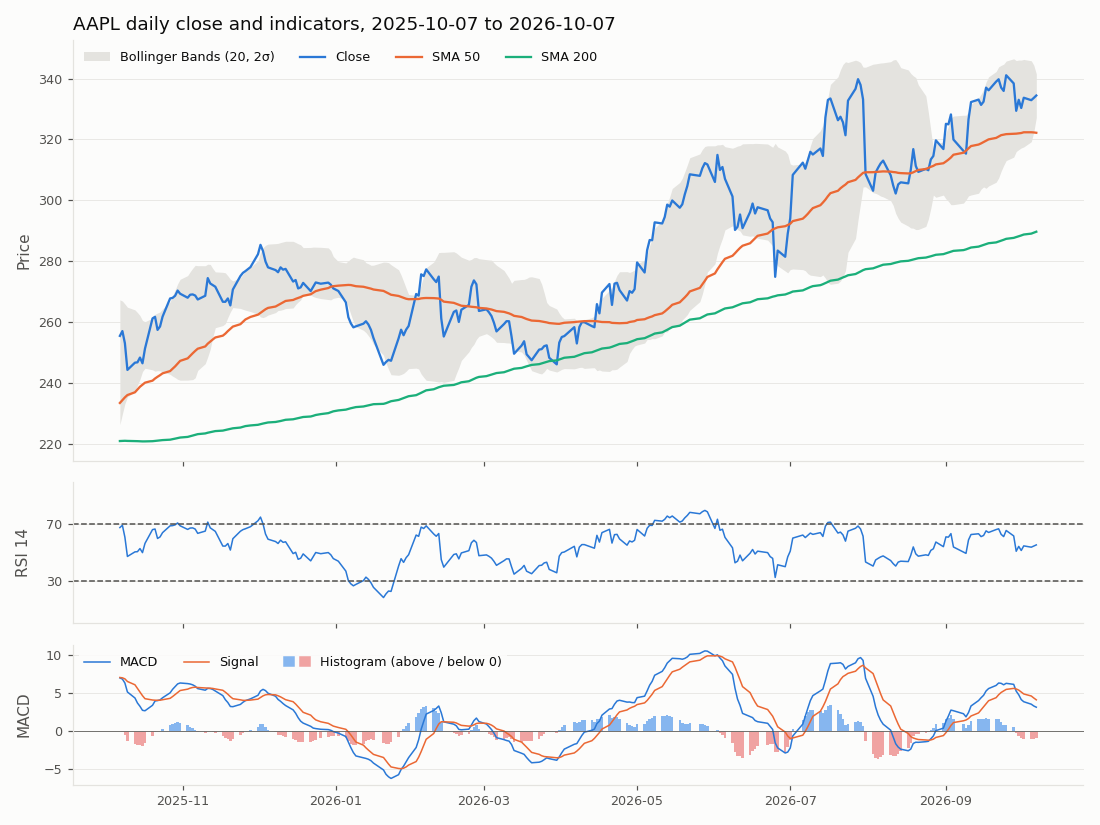

In [32]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 1 notebook and the bonus report as designed in the grilling rounds', Date: 2026-10-06
import html
from datetime import datetime

from IPython.display import Image, display

from task1_financial.pipeline import MARKET_TIMEZONE
from task1_financial.report import build_report, save_report

report = build_report(market, analysis, generated_at=datetime.now(MARKET_TIMEZONE))
for path in save_report(report):
    print("saved", path.relative_to(ROOT))
# An iframe keeps the page's own CSS from restyling the notebook.
display({"text/html": f'<iframe srcdoc="{html.escape(report.html)}" style="width:100%;height:1500px;border:0"></iframe>'}, raw=True)

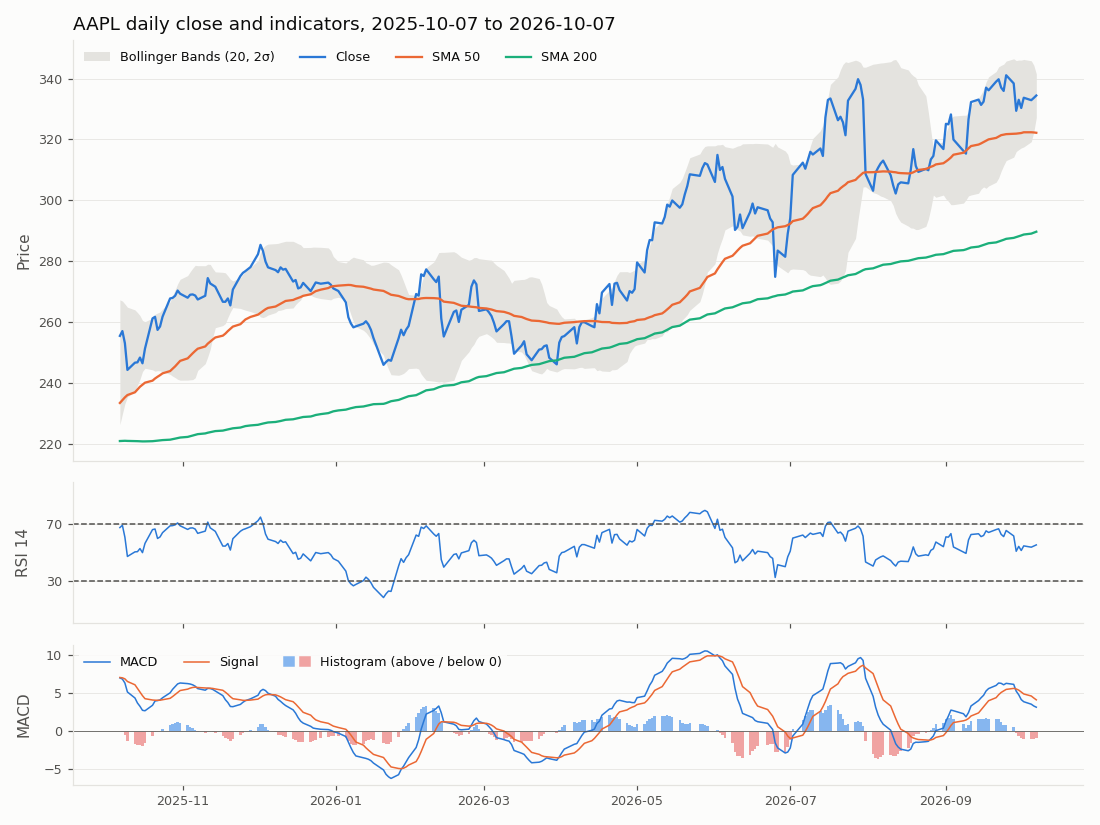

In [33]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 1 notebook and the bonus report as designed in the grilling rounds', Date: 2026-10-06
# The same chart as a plain PNG output, which GitHub's notebook viewer always shows.
Image(report.chart_png) if report.chart_png else print("no chart")

## Run summary

In [34]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 1 notebook and the bonus report as designed in the grilling rounds', Date: 2026-10-06
sentiment = analysis.sentiment
print(f"Ticker:          {summary['ticker']} ({summary['company_name']}), data as of {summary['as_of']}")
print(f"Recommendation:  {recommendation.value.recommendation} (ok={recommendation.ok}, by {recommendation.provider})")
print(f"Sentiment score: {sentiment.score:+.2f} ({sentiment.label})" if sentiment.score is not None else "Sentiment score: unavailable")
print(f"Headlines:       {len(market.headlines)} retrieved; labelled by Jev {sentiment.by_jev}, by the LLM {sentiment.by_llm}, failed {sentiment.failed}")
print(f"Warnings:        {len(summary['warnings'])} data, {len(analysis.warnings)} analysis")
print(f"Logged requests: {len(calls)} ({calls['outcome'].value_counts().to_dict()})")
print(f"Run time:        {time.perf_counter() - RUN_STARTED:.0f} s")

Ticker:          AAPL (Apple Inc.), data as of 2026-10-07
Recommendation:  Hold (ok=True, by groq)
Sentiment score: -0.41 (negative)
Headlines:       15 retrieved; labelled by Jev 0, by the LLM 14, failed 1
Warnings:        1 data, 2 analysis
Logged requests: 31 ({'fallback': 16, 'ok': 15})
Run time:        39 s


In [35]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 1 notebook and the bonus report as designed in the grilling rounds', Date: 2026-10-06
# Colab only: download the call log and the report, which are committed beside this notebook.
import zipfile

if IN_COLAB:
    from google.colab import files

    bundle = Path("/content/task1_run_outputs.zip")
    with zipfile.ZipFile(bundle, "w") as archive:
        for path in [CALL_LOG, *sorted((ROOT / "task1_financial" / "reports").glob(f"{TICKER}_*"))]:
            archive.write(path, path.relative_to(ROOT))
        print("bundled:", archive.namelist())
    files.download(str(bundle))
else:
    print("Local run: the log and the report are already in the repo.")

bundled: ['task1_financial/logs/llm_calls.jsonl', 'task1_financial/reports/AAPL_brief.html', 'task1_financial/reports/AAPL_brief.md', 'task1_financial/reports/AAPL_chart.png']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>